In [1]:
!pip install --upgrade "jax[cpu]"
import os
import numpy as np
import random
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.5/85.5 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 110.1 MB/s eta 0:00:00
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.7.2
    Uninstalling jaxlib-0.7.2:
      Successfully uninstalled jaxlib-0.7.2
  Attempting uninstall: jax
    Found existing installation: jax 0.7.2
    Uninstalling jax-0.7.2:
      Successfully uninstalled jax-0.7.2


/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.10.2, so it will not be used.
  warnings.warn(


In [2]:
!kaggle datasets download masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 202MB/s]



In [3]:
import zipfile

with zipfile.ZipFile("brain-tumor-mri-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("brain-tumor-mri-dataset")

In [4]:
train_dir = '/content/brain-tumor-mri-dataset/Training/'
test_dir = '/content/brain-tumor-mri-dataset/Testing/'

train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

# mixing the order of your dataset
train_paths, train_labels = shuffle(train_paths, train_labels)

test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

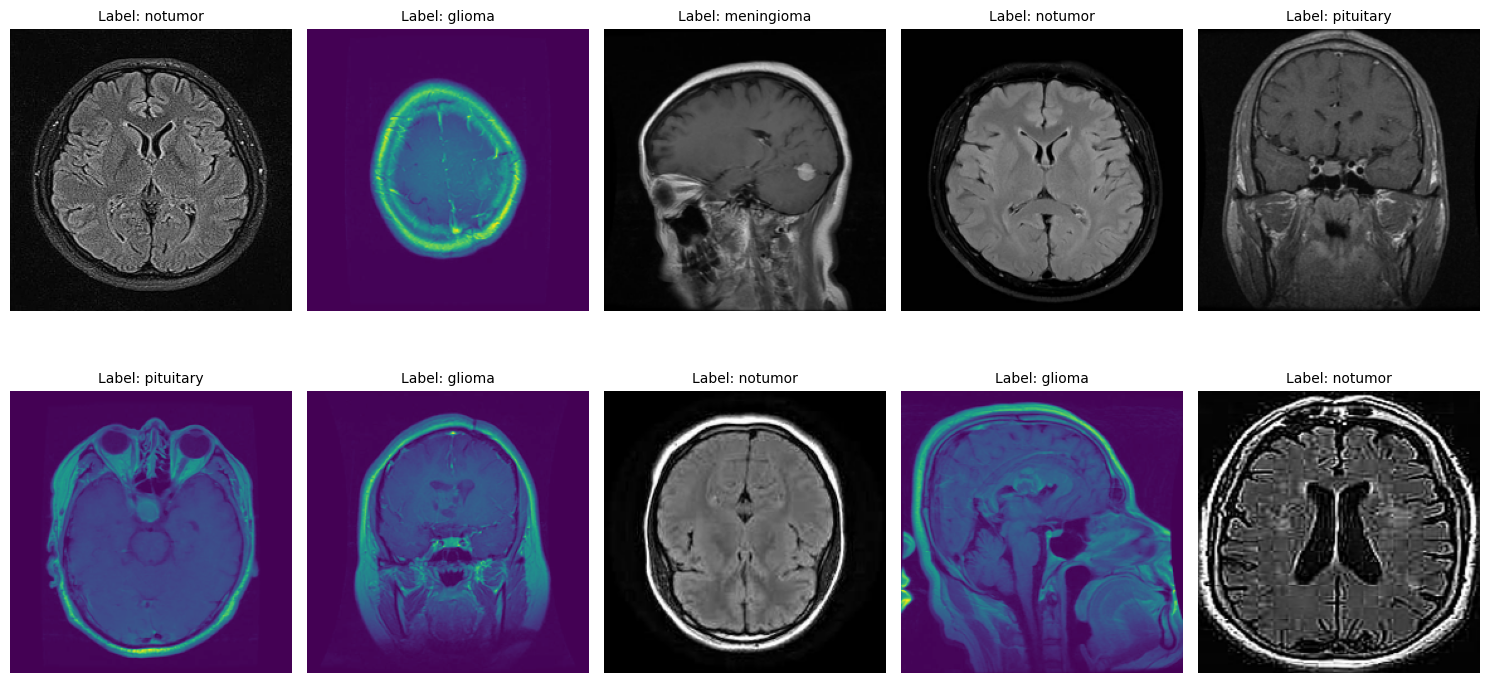

In [5]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

random_indices = random.sample(range(len(train_paths)), 10)

fig, axes = plt.subplots(2, 5, figsize=(15, 8))
# converts a 2D grid of subplot axes into a 1D array
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    # Load image
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))

    axes[i].imshow(img)
    axes[i].axis('off')
    # Display class label in the second row
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()

In [7]:
IMAGE_SIZE=128
# Image Augmentation function
def augment_image(image):
    # converts the NumPy array into a PIL image object.
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    image = np.array(image) / 255.0  # Normalize pixel values
    return image

def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

#  Encoding labels (convert label names to integers)
def encode_label(labels):
    unique_labels = os.listdir(train_dir)  # Ensure unique labels are determined
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)
            yield batch_images, batch_labels
            # (
  # [image5],
#  [1]
# )

**WE ARE USING VGG16 FOR TRANSFER LEARNING**


- VGG16, a pre-trained CNN model, is used as the base model for transfer learning.

- The model is loaded with ImageNet weights and without its original classification layers (include_top=False).

- All VGG16 layers are initially frozen to preserve the learned features.

- The last three layers are unfrozen and fine-tuned to adapt the model to the new dataset.
The VGG16 base model is added to a Sequential model.

- A Flatten layer is used to convert the extracted feature maps into a one-dimensional vector.

- A Dropout layer (0.3) is added to reduce overfitting.

- A Dense layer with 128 neurons and ReLU activation is used to learn high-level features.

- A second Dropout layer (0.2) is added for additional regularization.

- The final Dense layer uses a Softmax activation function to output the probability of each class.


In [8]:
# Model architecture
IMAGE_SIZE = 128
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Input layer
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

batch_size = 20
steps = int(len(train_paths) / batch_size)
epochs = 10

history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step - loss: 0.4634 - sparse_categorical_accuracy: 0.8189
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - loss: 0.2488 - sparse_categorical_accuracy: 0.9064
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 60ms/step - loss: 0.1654 - sparse_categorical_accuracy: 0.9413
Epoch 4/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 59ms/step - loss: 0.1218 - sparse_categorical_accuracy: 0.9561
Epoch 5/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 59ms/step - loss: 0.0846 - sparse_categorical_accuracy: 0.9700
Epoch 6/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 62ms/step - loss: 0.0588 - sparse_categorical_accuracy: 0.9798
Epoch 7/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 61ms/step - loss: 0.0616 - sparse_categorical_accuracy: 0.9762
Epoch 8/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 61ms/step - loss: 0.0484 - sparse_categorical_accuracy: 0.9825
Epoch 9/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 61ms/step - loss: 0.0371 - sparse_categorical_acc

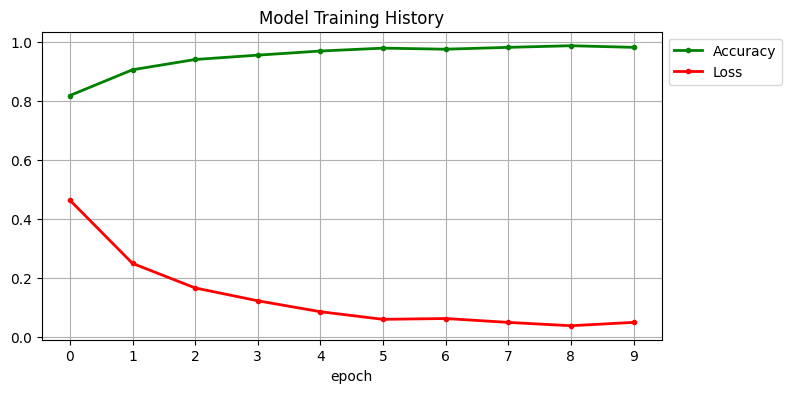

In [9]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.99      0.91       400
           1       0.99      0.72      0.83       400
           2       0.91      1.00      0.95       400
           3       0.98      0.97      0.98       400

    accuracy                           0.92      1600
   macro avg       0.93      0.92      0.92      1600
weighted avg       0.93      0.92      0.92      1600



In [11]:
len(test_paths+train_paths)

7200

Confusion Matrix:
[[396   2   0   2]
 [ 68 288  39   5]
 [  0   0 400   0]
 [  8   1   1 390]]


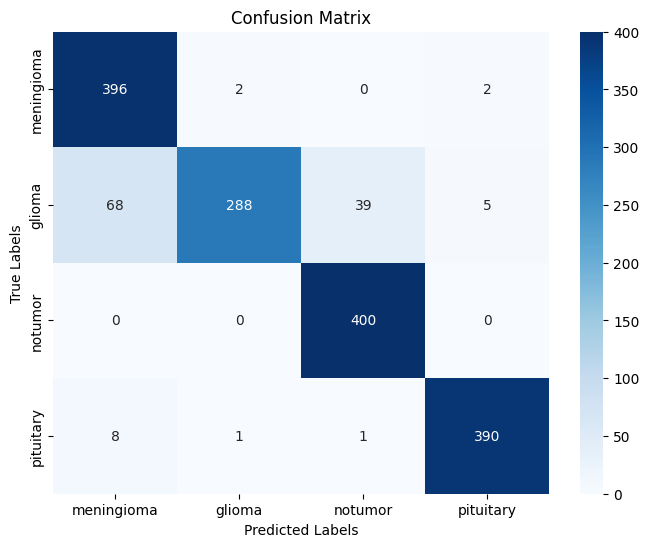

In [12]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()